# Week 14 - GEOG 6670 & 4670 
# Final Project Concepts
Population, impacts, environemntal data aggregation

---
### Project Management & Programming - Spring 2026
- Lecture: Tuesday - 6:00pm-8:30pm - Wood 2722 or Virtual WebEx   
- Eric M Kerney: eric.m.kerney@wmich.edu
- Office Hours VIRTUAL: WebEx Thurs - 7:00pm-8:00pm    
- https://wmich.webex.com/meet/eric.m.kerney

In [2]:
import ee
import geemap
import os
import geopandas as gpd

In [ ]:
Map = geemap.Map()
Map

In [5]:
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

```python
Working with this Population Density data from Earth Engine:
"CIESIN/GPWv411/GPW_Population_Density"
```

In [4]:
# preset visualization colors from the GEE sample JS Code 

dataset = ee.ImageCollection('CIESIN/GPWv411/GPW_Population_Density').first();
raster = dataset.select('population_density');
raster_vis = {
  'max': 1000.0,
  'palette': [
    'ffffe7',
    'FFc869',
    'ffac1d',
    'e17735',
    'f2552c',
    '9f0c21'
  ],
  'min': 200.0
};
Map.setCenter(79.1, 19.81, 3);
Map.addLayer(raster, raster_vis, 'population_density');

```python
This is the landscan population data from the GEE Community Datasets:
"projects/sat-io/open-datasets/ORNL/LANDSCAN_GLOBAL"
```

In [5]:
landscan_global = ee.ImageCollection('projects/sat-io/open-datasets/ORNL/LANDSCAN_GLOBAL');
popcount_intervals = '<RasterSymbolizer>' + ' <ColorMap type="intervals" extended="false" >' + \
    '<ColorMapEntry color="#CCCCCC" quantity="0" label="No Data"/>' + \
    '<ColorMapEntry color="#FFFFBE" quantity="5" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#FEFF73" quantity="25" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#FEFF2C" quantity="50" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#FFAA27" quantity="100" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#FF6625" quantity="500" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#FF0023" quantity="2500" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#CC001A" quantity="5000" label="Population Count (Estimate)"/>' + \
    '<ColorMapEntry color="#730009" quantity="185000" label="Population Count (Estimate)"/>' + \
    '</ColorMap>' + '</RasterSymbolizer>'

dict = {
  'names': [
    '0', '1-5', '6-25', '26-50', '51-100', '101-500', '501-2500', '2501-5000',
    '5001-185000'
  ],
  'colors': [
    '#CCCCCC', '#FFFFBE', '#FEFF73', '#FEFF2C', '#FFAA27', '#FF6625', '#FF0023',
    '#CC001A', '#730009'
  ]
};

Map.addLayer(
    landscan_global.sort('system:time_start')
        .first()
        .sldStyle(popcount_intervals),
    {}, 'Population Count Estimate 2000');
Map.addLayer(
    landscan_global.sort('system:time_start', False)
        .first()
        .sldStyle(popcount_intervals),
    {}, 'Population Count Estimate 2022');

```python 
Now Let's bring in Michigan Counties and attempt to use those to join with the population data.
We've seen this with point data example, though not with polygon yet
Here is the Michigan Counties data GeoJSON from MI Open Data, load into a Geodataframe
```

In [6]:
url = "https://services3.arcgis.com/dxRQUfTDNtfqZ301/arcgis/rest/services/County/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson"
gdf_mi_counties = gpd.read_file(url)
gdf_mi_counties.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   OBJECTID       83 non-null     int32   
 1   FIPSCode       83 non-null     object  
 2   Name           83 non-null     object  
 3   FeatureID      83 non-null     object  
 4   MapLayout      83 non-null     object  
 5   FIPSNum        83 non-null     int32   
 6   Label          83 non-null     object  
 7   Type           83 non-null     object  
 8   CntyCode       83 non-null     object  
 9   Peninsula      82 non-null     object  
 10  MGFVersion     83 non-null     object  
 11  Shape__Area    83 non-null     float64 
 12  Shape__Length  83 non-null     float64 
 13  GlobalID       83 non-null     object  
 14  geometry       83 non-null     geometry
dtypes: float64(2), geometry(1), int32(2), object(10)
memory usage: 9.2+ KB


#### Let's test with ONE county to Extract Data from GEE 
Should be much faster than all 83...

In [7]:
gdf_mi_test = gpd.read_file(url, rows=1)
gdf_mi_test.head()

,OBJECTID,FIPSCode,Name,FeatureID,MapLayout,FIPSNum,Label,Type,CntyCode,Peninsula,MGFVersion,Shape__Area,Shape__Length,GlobalID,geometry
0,342,001,Alcona,51931f35-ce9a-491b-b699-49036d732254,landscape,1,Alcona County,County,1,Lower,V26,1.798557e+09,172519.815622,324fedbc-244e-40ef-89e2-ca15d2fdf578,"POLYGON ((-83.31858 44.51165, -83.31859 44.511..."


#### Attempt to convert to EE Layer...

In [ ]:
selection_layer = geemap.gdf_to_ee(gdf_mi_test)
selection_layer

#### Looks promising!

In [ ]:
Map.addLayer(selection_layer, {}, "Counties Test")
Map

![alt text](week14-final-county.png)

```python
Use the .first() method to extract a single band 
If we don't provide an output path, the function returns an 
in memory GEE Feature Collection
```

In [ ]:
dataset = ee.ImageCollection('CIESIN/GPWv411/GPW_Population_Density').first()
geemap.extract_values_to_points(selection_layer, dataset)

#### This works - though only one pop_density value 
- This is due to the extract_values_to_points() 
- Though we need to get the mean over our county polygon 

> First let's take a look at the Population_Density Data


In [11]:
# Only one population band 
dataset = ee.ImageCollection('CIESIN/GPWv411/GPW_Population_Density').first()
dataset.bandNames()

#### Select the most current data for 2020

In [12]:
pop_den_gpw_2020 = (
    ee.ImageCollection('CIESIN/GPWv411/GPW_Population_Density')
    .filterDate('2020-01-01', '2021-01-01')
    .first()
)
gpw_raster = pop_den_gpw_2020.select('population_density')

```python 
This is the key to getting statistics for the ENTIRE polygon 
reduceRegions() performs calculations on ALL Cells within the polygon
```

In [13]:
# get the native resolution of the raster 
scale = gpw_raster.projection().nominalScale()
# for each polygon, look at all pixels inside and compute stats
county_stats = gpw_raster.reduceRegions(
    collection=selection_layer,
    reducer=(
        ee.Reducer.count()
        .combine(ee.Reducer.mean(), sharedInputs=True)
        .combine(ee.Reducer.median(), sharedInputs=True)
        .combine(ee.Reducer.minMax(), sharedInputs=True)
        .combine(ee.Reducer.stdDev(), sharedInputs=True)
    ),
    scale=scale,
    tileScale=4,
    crs=gpw_raster.projection(),
)
geemap.ee_to_gdf(county_stats).head()

,geometry,CntyCode,FIPSCode,FIPSNum,FeatureID,GlobalID,Label,MGFVersion,MapLayout,Name,...,Peninsula,Shape__Area,Shape__Length,Type,count,max,mean,median,min,stdDev
0,"POLYGON ((-83.88859 44.71141, -83.88844 44.700...",1,001,1,51931f35-ce9a-491b-b699-49036d732254,324fedbc-244e-40ef-89e2-ca15d2fdf578,Alcona County,V26,landscape,Alcona,...,Lower,1.798557e+09,172519.815622,County,3035,394.966705,6.623695,0.506908,0,20.726095


#### Do the same for ALL Counties

In [14]:
url = "https://services3.arcgis.com/dxRQUfTDNtfqZ301/arcgis/rest/services/County/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson"
gdf_mi_counties = gpd.read_file(url)
gdf_mi_counties["county_id"] = gdf_mi_counties.index
gdf_mi_counties.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   OBJECTID       83 non-null     int32   
 1   FIPSCode       83 non-null     object  
 2   Name           83 non-null     object  
 3   FeatureID      83 non-null     object  
 4   MapLayout      83 non-null     object  
 5   FIPSNum        83 non-null     int32   
 6   Label          83 non-null     object  
 7   Type           83 non-null     object  
 8   CntyCode       83 non-null     object  
 9   Peninsula      82 non-null     object  
 10  MGFVersion     83 non-null     object  
 11  Shape__Area    83 non-null     float64 
 12  Shape__Length  83 non-null     float64 
 13  GlobalID       83 non-null     object  
 14  geometry       83 non-null     geometry
 15  county_id      83 non-null     int64   
dtypes: float64(2), geometry(1), int32(2), int64(1), object(10)
memory usage: 9

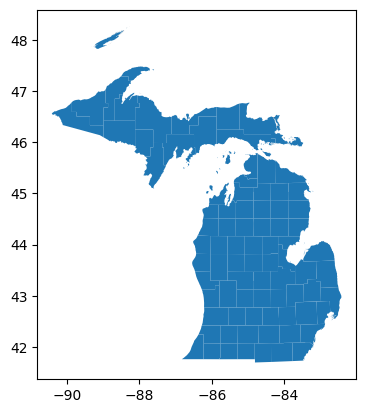

In [15]:
gdf_mi_counties_ee = gdf_mi_counties[["county_id", "geometry"]].to_crs(5070).copy()
gdf_mi_counties_ee["geometry"] = gdf_mi_counties_ee.geometry.simplify(250, preserve_topology=True)
gdf_mi_counties_ee = gdf_mi_counties_ee.to_crs(4326)

gdf_mi_counties_ee.plot();

In [16]:
full_selection_layer = geemap.gdf_to_ee(gdf_mi_counties_ee)

In [17]:
scale = gpw_raster.projection().nominalScale()
county_stats = gpw_raster.reduceRegions(
    collection=full_selection_layer,
    reducer=(
        ee.Reducer.count()
        .combine(ee.Reducer.mean(), sharedInputs=True)
        .combine(ee.Reducer.median(), sharedInputs=True)
        .combine(ee.Reducer.minMax(), sharedInputs=True)
        .combine(ee.Reducer.stdDev(), sharedInputs=True)
    ),
    scale=scale,
    tileScale=4,
    crs=gpw_raster.projection(),
)

# Drop geometries before bringing the results back to Python.
county_stats_table = county_stats.map(
    lambda feature: ee.Feature(None, feature.toDictionary())
)
county_stats_df = geemap.ee_to_df(county_stats_table)

gdf_merged = gdf_mi_counties.merge(county_stats_df, on="county_id")
gdf_merged.head(3)

,OBJECTID,FIPSCode,Name,FeatureID,MapLayout,FIPSNum,Label,Type,CntyCode,Peninsula,...,Shape__Length,GlobalID,geometry,county_id,count,max,mean,median,min,stdDev
0,342,001,Alcona,51931f35-ce9a-491b-b699-49036d732254,landscape,1,Alcona County,County,1,Lower,...,172519.815622,324fedbc-244e-40ef-89e2-ca15d2fdf578,"POLYGON ((-83.31858 44.51165, -83.31859 44.511...",0,3014,394.966705,6.654160,0.507053,0.0,20.695107
1,343,003,Alger,8c7dd4c5-6ac6-4734-842a-9435187285a1,landscape,3,Alger County,County,3,Upper,...,390876.655767,65f15d53-82e4-46d8-a8c0-5c5d27749c7e,"MULTIPOLYGON (((-86.71656 46.47932, -86.71653 ...",1,4353,928.313477,4.086336,0.690789,0.0,27.035758
2,344,005,Allegan,174ea398-4ee3-4ab0-ac6e-6e91d33a682b,landscape,5,Allegan County,County,5,Lower,...,192581.537228,e7e824d2-8e9d-4a54-9ca5-b86a82a9f815,"POLYGON ((-85.5432 42.42144, -85.54645 42.4214...",2,3585,1896.311279,56.105105,27.893938,0.0,131.543598


In [18]:
gdf_merged['mean'].sort_values(ascending=False)

81    1009.636477
49     722.480163
62     542.006938
40     285.667331
24     252.030332
         ...     
35       3.576289
76       2.954322
47       2.789173
65       1.845357
41       1.488891
Name: mean, Length: 83, dtype: float64

In [4]:
import matplotlib.pyplot as plt
from enum import Enum
class ColorRamps(Enum):
    SEISMIC = 'seismic'
    MAGMA = 'magma'
    INFERNO = 'inferno'
    VIRIDIS = 'viridis'
    CIVIDIS = 'cividis'
    RAINBOW = 'rainbow'

class Schemes(Enum):
    NATURAL_BREAKS = 'natural_breaks'
    QUANTILES = 'quantiles'
    EQUAL_INTERVAL = 'equal_interval'

def plot_map_by_column(
        gdf: gpd.GeoDataFrame, 
        column: str, 
        color_ramp: ColorRamps, 
        scheme: Schemes,
        title: str):
    fig, ax = plt.subplots(figsize=(12, 8), facecolor="#1a1a1a")
    plot = gdf.plot(
        ax=ax,
        column=column,
        cmap=color_ramp.value,
        edgecolor="white",
        linewidth=0.3,
        legend=True,
        scheme=scheme.value,
        legend_kwds={
            'labelcolor': 'white',
            "loc": "center left", 
            'frameon': False},
        alpha=0.6
    )
    plt.title(f"{title}", fontsize=16, color="white")
    ax.set_axis_off()

In [ ]:
plot_map_by_column(
    gdf_merged, 
    'mean', 
    ColorRamps.RAINBOW, 
    Schemes.QUANTILES, 
     'Mean Population Density')

## Enviro Data 
Whew that was defintely a process to join the counties with mean population density from Earth Engine!  
Now we need to bring in some environmental or hazard layers to overlay with these populations.    
You will need at least 3 to provide some depth to your analysis.    
Let's look a couple layers here, Formerly Used Defense Sites(HIFLD) & Solid Waste Landfills(EGLE) 

In [21]:
defense_URL = 'https://hifld.publicenvirodata.org/storage/formerly-used-defense-sites-public-mrs/formerly-used-defense-sites-public-mrs-geopackage/geojson/formerly-used-defense-sites-public-mrs-geojson.geojson'
gdf_defense = gpd.read_file(defense_URL)
gdf_defense.head(3)

,OBJECTID,FEATUREDESCRIPTION,FEATURENAME,FUDSINSTALLATIONID,MEDIAID,SDSID,FISCALYEAR,USACEDIVISION,USACEDISTRICT,DERPPROGRAM,...,FUDSPROPERTYID,FUDSSITEID,OFFICIALSITENAME,PROJECTCATEGORY,PROJECTNUMBER,PROJECTSTATUS,RELATIVEPRIORITY,STATEORTERRITORYNAME,SE_ANNO_CAD_DATA,geometry
0,1,None,Rocket Range,CA99799F755700,None,None,2022.0,spd,spl,mmrp,...,J09CA0172,01,None,None,J09CA017201,investigation,None,ca,,"POLYGON Z ((-115.23573 32.9484 0, -115.26626 3..."
1,2,None,Multiple Use Range Complex,CA99799F540400,None,None,2022.0,spd,spl,mmrp,...,J09CA0288,01,None,None,J09CA028801,investigation,None,ca,,"MULTIPOLYGON Z (((-114.7329 32.79371 0, -114.7..."
2,3,None,Combat Ranges,TX69799F646400,None,None,2022.0,swd,swf,mmrp,...,K06TX0034,14,None,None,K06TX003414,investigation,None,tx,,"MULTIPOLYGON Z (((-98.05204 32.90653 0, -98.04..."


In [22]:
landfills_URL = 'https://gisagoegle.state.mi.us/arcgis/rest/services/EGLE/MmdOpenData/MapServer/6/query?outFields=*&where=1%3D1&f=geojson'
gdf_landfills = gpd.read_file(landfills_URL)
gdf_landfills.head(3)

,OID,show,module,wdsid,legalsitename,specificsitename,actcode,facilitytype,addrline1,addrline2,...,compostregexprdate,ewasteregexprdate,scraptirestatus,scraptireexprdate,endusercmpltype,endusercmpldate,disposalareastatus,landfilllink,Shape,geometry
0,3,1,SolidWaste,390701,REPUBLIC SERVICES OF MICHIGAN I LLC,CARLETON FARMS LANDFILL,II,Type II MSW Landfill,28800 CLARK RD,,...,None,None,None,None,None,None,Active - Accepting,https://www.michigan.gov/egle/about/organizati...,None,POINT (-83.42138 42.09359)
1,4,1,SolidWaste,390701,REPUBLIC SERVICES OF MICHIGAN I LLC,CARLETON FARMS LANDFILL,II-Ash,Type II MSW Incinerator Ash Landfill,28800 CLARK RD,,...,None,None,None,None,None,None,Active - Accepting,https://www.michigan.gov/egle/about/organizati...,None,POINT (-83.42138 42.09359)
2,8,1,SolidWaste,391216,GFL ENVIRONMENTAL USA INC,GFL NORTH MICHIGAN LANDFILL LLC,II,Type II MSW Landfill,20667 5 MILE HWY,,...,None,None,None,None,None,None,Active - Accepting,https://www.michigan.gov/egle/about/organizati...,None,POINT (-84.2192 45.28235)


In [23]:
# Check that both gdf's are in same crs 
print(f'Merged gdf: {gdf_merged.crs} - Landfills: {gdf_landfills.crs}')


Merged gdf: EPSG:4326 - Landfills: EPSG:4326


In [24]:
# Spatial join: 'within' or 'intersects' are common predicates
joined = gpd.sjoin(gdf_landfills, gdf_merged, how='inner', predicate='within')
counts = joined.groupby('index_right').size()
counts.head()

index_right
1     1
3     1
7     1
8     1
10    2
dtype: int64

In [25]:
gdf_merged['landfill_count'] = gdf_merged.index.map(counts).fillna(0)
gdf_merged.head(2)


,OBJECTID,FIPSCode,Name,FeatureID,MapLayout,FIPSNum,Label,Type,CntyCode,Peninsula,...,GlobalID,geometry,county_id,count,max,mean,median,min,stdDev,landfill_count
0,342,001,Alcona,51931f35-ce9a-491b-b699-49036d732254,landscape,1,Alcona County,County,1,Lower,...,324fedbc-244e-40ef-89e2-ca15d2fdf578,"POLYGON ((-83.31858 44.51165, -83.31859 44.511...",0,3014,394.966705,6.654160,0.507053,0.0,20.695107,0.0
1,343,003,Alger,8c7dd4c5-6ac6-4734-842a-9435187285a1,landscape,3,Alger County,County,3,Upper,...,65f15d53-82e4-46d8-a8c0-5c5d27749c7e,"MULTIPOLYGON (((-86.71656 46.47932, -86.71653 ...",1,4353,928.313477,4.086336,0.690789,0.0,27.035758,1.0


In [26]:
gdf_merged['geometry'].crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [27]:
# We should reproject into projected CRS 
gdf_defense.to_crs(epsg=5070, inplace=True)
gdf_merged.to_crs(epsg=5070, inplace=True)
gdf_merged.crs

<Projected CRS: EPSG:5070>
Name: NAD83 / Conus Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - CONUS onshore - Alabama; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming.
- bounds: (-124.79, 24.41, -66.91, 49.38)
Coordinate Operation:
- name: Conus Albers
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [28]:
# 1. Overlay intersection (clips defense sites to county boundaries)
intersections = gpd.overlay(gdf_defense, gdf_merged, how="intersection")
# 2. Calculate the area of each intersected piece
intersections['defense_site_area'] = intersections.geometry.area
intersections['defense_site_area'].head()


0    6.372810e+06
1    9.043767e+05
2    2.531118e+07
3    6.602248e+06
4    2.203374e+06
Name: defense_site_area, dtype: float64

#### This makes more sense in non-scientific notation
Units are in square meters for Area, as we see above in the CRS info

In [29]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
intersections['defense_site_area'].head()


0    6372810.01
1     904376.70
2   25311176.32
3    6602247.67
4    2203374.29
Name: defense_site_area, dtype: float64

In [30]:
# 3. Aggregate area per county using 'county_id'
county_site_area = intersections.groupby('county_id')['defense_site_area'].sum().reset_index()
county_site_area.head()

,county_id,defense_site_area
0,0,25311176.32
1,12,3683802.15
2,14,60853.11
3,16,6973275.07
4,25,194151.44


In [31]:
# 4. Merge results back to original counties layer
gdf_merged_final = gdf_merged.merge(county_site_area, on='county_id', how='left').fillna(0)
gdf_merged_final.head(3)

,OBJECTID,FIPSCode,Name,FeatureID,MapLayout,FIPSNum,Label,Type,CntyCode,Peninsula,...,geometry,county_id,count,max,mean,median,min,stdDev,landfill_count,defense_site_area
0,342,001,Alcona,51931f35-ce9a-491b-b699-49036d732254,landscape,1,Alcona County,County,1,Lower,...,"POLYGON ((1002848.217 2458357.974, 1002847.727...",0,3014,394.97,6.65,0.51,0.00,20.70,0.00,25311176.32
1,343,003,Alger,8c7dd4c5-6ac6-4734-842a-9435187285a1,landscape,3,Alger County,County,3,Upper,...,"MULTIPOLYGON (((713820.994 2644918.355, 713824...",1,4353,928.31,4.09,0.69,0.00,27.04,1.00,0.00
2,344,005,Allegan,174ea398-4ee3-4ab0-ac6e-6e91d33a682b,landscape,5,Allegan County,County,5,Lower,...,"POLYGON ((853331.596 2205038.445, 853067.091 2...",2,3585,1896.31,56.11,27.89,0.00,131.54,0.00,0.00


In [32]:
gdf_test = gdf_merged_final[['landfill_count', 'defense_site_area', 'county_id']]
gdf_test.head(10)

,landfill_count,defense_site_area,county_id
0,0.00,25311176.32,0
1,1.00,0.00,1
2,0.00,0.00,2
3,1.00,0.00,3
4,0.00,0.00,4
5,0.00,0.00,5
6,0.00,0.00,6
7,1.00,0.00,7
8,1.00,0.00,8
9,0.00,0.00,9


#### Convert sq m into sq km

In [33]:
gdf_test['defense_sq_km'] = gdf_test.apply(lambda row: row[1] / 1000000, axis=1)
gdf_test['defense_sq_km'].unique()

array([25.31117632,  0.        ,  3.68380215,  0.06085311,  6.97327507,
        0.19415144,  6.60224767,  4.3883383 ,  0.86848573,  0.34107988])

#### Not many defense sites in Michigan Counties 
We can try to plot this   
.plot() won't provide enough detail as a nationwide dataset 
Perfect use for `.explore()`  
I need to close and open my notebook to get the map to render

In [ ]:
gdf_defense.explore()

In [35]:
gdf_test.head()

,landfill_count,defense_site_area,county_id,defense_sq_km
0,0.00,25311176.32,0,25.31
1,1.00,0.00,1,0.00
2,0.00,0.00,2,0.00
3,1.00,0.00,3,0.00
4,0.00,0.00,4,0.00


```python
Now for the big moment!  
Let's hack together an Environmental Risk score, somewhat arbitrary to start 
We've almost got the landfills and defense sites at the same order of magnitude 
Landfills range from 0-7 
Defense Site Area ranges from 0-25 sq km 
We can use a pandas .apply() with a lambda function to create a new column 
Here we create a new 'enviro_risk' column
We'll multiply landfills by 5  and add that number to the defense site sq km 
```

In [36]:
gdf_test['enviro_risk'] = gdf_test.apply(lambda row: (row[0] * 5) + row[3], axis=1)
gdf_test['enviro_risk'].describe()

count   83.00
mean     4.74
std      6.53
min      0.00
25%      0.00
50%      5.00
75%      5.00
max     35.00
Name: enviro_risk, dtype: float64

### We've got an Enviro Risk Score! 
mean = 4.74, max = 35, min = 0  
Seems reasonable

---
Now we need to join it back to gdf_merged

In [37]:
final_gdf = gdf_merged.join(gdf_test)

ValueError: columns overlap but no suffix specified: Index(['county_id', 'landfill_count'], dtype='object')

In [ ]:
# That didn't work, let's try .merge()
final_gdf = pd.merge(gdf_merged, gdf_test, on='county_id')
final_gdf.head(5)

,OBJECTID,FIPSCode,Name,FeatureID,MapLayout,FIPSNum,Label,Type,CntyCode,Peninsula,...,max,mean,median,min,stdDev,landfill_count_x,landfill_count_y,defense_site_area,defense_sq_km,enviro_risk
0,342,001,Alcona,51931f35-ce9a-491b-b699-49036d732254,landscape,1,Alcona County,County,1,Lower,...,394.97,6.65,0.51,0.00,20.70,0.00,0.00,25311176.32,25.31,25.31
1,343,003,Alger,8c7dd4c5-6ac6-4734-842a-9435187285a1,landscape,3,Alger County,County,3,Upper,...,928.31,4.09,0.69,0.00,27.04,1.00,1.00,0.00,0.00,5.00
2,344,005,Allegan,174ea398-4ee3-4ab0-ac6e-6e91d33a682b,landscape,5,Allegan County,County,5,Lower,...,1896.31,56.11,27.89,0.00,131.54,0.00,0.00,0.00,0.00,0.00
3,345,007,Alpena,ee696d1a-c271-4a50-90f1-96c683eebd97,landscape,7,Alpena County,County,7,Lower,...,1886.16,19.99,2.86,0.00,95.06,1.00,1.00,0.00,0.00,5.00
4,346,009,Antrim,a349ee7e-448e-40bb-8bbb-cdf44a483d6e,landscape,9,Antrim County,County,9,Lower,...,823.23,21.47,10.00,0.00,51.11,0.00,0.00,0.00,0.00,0.00


In [ ]:
# 4326 looks a bit better on the map
final_gdf.to_crs(epsg=4326, inplace=True) 
# reuse our map by column function 

plot_map_by_column(
    final_gdf, 
    'enviro_risk', 
    ColorRamps.RAINBOW, 
    Schemes.NATURAL_BREAKS, 
     'Calculated Enviro Risk Score')

# NOT BAD!
- It appears that the large number of landfills in Wayne County is giving a high score 
- Alcona and Calhoun Counties have old defense sites which is impacting them
- Label for the county names would be nice right?  
- There is much more that can be done, adding more risk factors 
- Adjusting the calculation values   
- We haven't even added the average population density into the calculation!?!  
- We'll take a look at that in class this week